<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/Notebook5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

# Data and the State (DATA 20195/30195)
# Lab 5: Tracking donated organs

This week we'll use a reduced version of a fairly sensitive dataset to understand several decades of history in the flow of donated livers, kidneys, and pancreases.

We went through a [data request process](https://optn.transplant.hrsa.gov/data/view-data-reports/request-data/data-request-instructions/) with the Organ Procurement and Transplantation Network (OPTN) to get a robust dataset based on STAR (Standard Transplant Analysis and Research) files.  Because lots of personal information was added that's potentially identifying, we're being very careful with the files.  You can access the prepared data through a dropbox link for use with this notebook, and we'll ask that you delete it at the end of the quarter. This is not published in github, so please email course staff for the link if you're not in lab in person.

In [2]:
!pip install -q geopy seaborn statsmodels

In [3]:
import sqlite3

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from functools import partial

from geopy.distance import distance as geodesic_distance
from shapely.geometry import Point

In [4]:
# @markdown This code cell contains a helper function for our backup data. Feel free to ignore.
import requests
import io
def read_parquet_from_github(url):
    r = requests.get(url)
    return gpd.read_parquet(io.BytesIO(r.content))

In [5]:
# you will have to download the sqlite dataset from the secure location and point at the right path here

optn_df = pd.read_sql("SELECT * FROM optn", sqlite3.connect("/content/optn_reduced.sqlite3"))
optn_df["deceased_donor"] = optn_df["deceased_donor"].astype(bool)
optn_df["succeeded_1_year"] = optn_df["succeeded_1_year"].astype(bool)

In [6]:
optn_df

,preservation_hours,recipient_age,donor_age,organ,deceased_donor,succeeded_1_year,donor_lat,donor_lon,transplant_lat,transplant_lon,transplant_year
0,6.1,30-59,60-99,liver,True,True,43.15,-75.18,42.27,-71.76,2017-2024
1,5.0,60-99,0-29,liver,True,True,41.25,-75.88,39.96,-75.20,2007-2016
2,5.7,30-59,30-59,liver,True,False,38.03,-84.51,35.13,-90.00,2017-2024
3,7.5,30-59,60-99,liver,True,True,37.66,-121.02,37.76,-122.46,2007-2016
4,5.3,30-59,0-29,liver,True,False,39.70,-104.84,40.66,-111.89,2017-2024
...,...,...,...,...,...,...,...,...,...,...,...
252054,9.4,30-59,30-59,pancreas,True,True,39.68,-105.16,32.24,-110.94,2017-2024
252055,0.2,30-59,0-29,pancreas,True,True,40.65,-73.93,40.79,-73.94,2017-2024
252056,15.5,30-59,30-59,pancreas,True,True,39.32,-81.51,40.00,-83.02,2007-2016
252057,10.5,30-59,0-29,pancreas,True,False,33.51,-86.80,38.92,-77.09,2017-2024


This block defines distance between the hospitals.  Since it's based on latitude and longitude, this is distance "as the crow flies."  (In future notebooks, we'll examine transit time options.)

In [7]:
def transplant_distance_miles(row):
    return geodesic_distance(
        (row["donor_lat"], row["donor_lon"]),
        (row["transplant_lat"], row["transplant_lon"])
    ).miles

In [8]:
optn_df["distance_miles"] = optn_df.apply(transplant_distance_miles, axis=1)

In [9]:
optn_df

,preservation_hours,recipient_age,donor_age,organ,deceased_donor,succeeded_1_year,donor_lat,donor_lon,transplant_lat,transplant_lon,transplant_year,distance_miles
0,6.1,30-59,60-99,liver,True,True,43.15,-75.18,42.27,-71.76,2017-2024,184.370227
1,5.0,60-99,0-29,liver,True,True,41.25,-75.88,39.96,-75.20,2007-2016,95.925424
2,5.7,30-59,30-59,liver,True,False,38.03,-84.51,35.13,-90.00,2017-2024,364.858865
3,7.5,30-59,60-99,liver,True,True,37.66,-121.02,37.76,-122.46,2007-2016,79.198770
4,5.3,30-59,0-29,liver,True,False,39.70,-104.84,40.66,-111.89,2017-2024,378.821725
...,...,...,...,...,...,...,...,...,...,...,...,...
252054,9.4,30-59,30-59,pancreas,True,True,39.68,-105.16,32.24,-110.94,2017-2024,606.372260
252055,0.2,30-59,0-29,pancreas,True,True,40.65,-73.93,40.79,-73.94,2017-2024,9.674583
252056,15.5,30-59,30-59,pancreas,True,True,39.32,-81.51,40.00,-83.02,2007-2016,93.186212
252057,10.5,30-59,0-29,pancreas,True,False,33.51,-86.80,38.92,-77.09,2017-2024,657.765094


In [10]:
organs = ["Liver", "Kidney"]

How many of each kind of organ do we have in the data?

In [11]:
optn_df["organ"].value_counts()

,count
organ,
kidney,145246
liver,104246
pancreas,2567


For organs that were moved (distance>0), let's make a histogram to see the distribution of the **cold ischemic time** (time out of the body and on ice).  

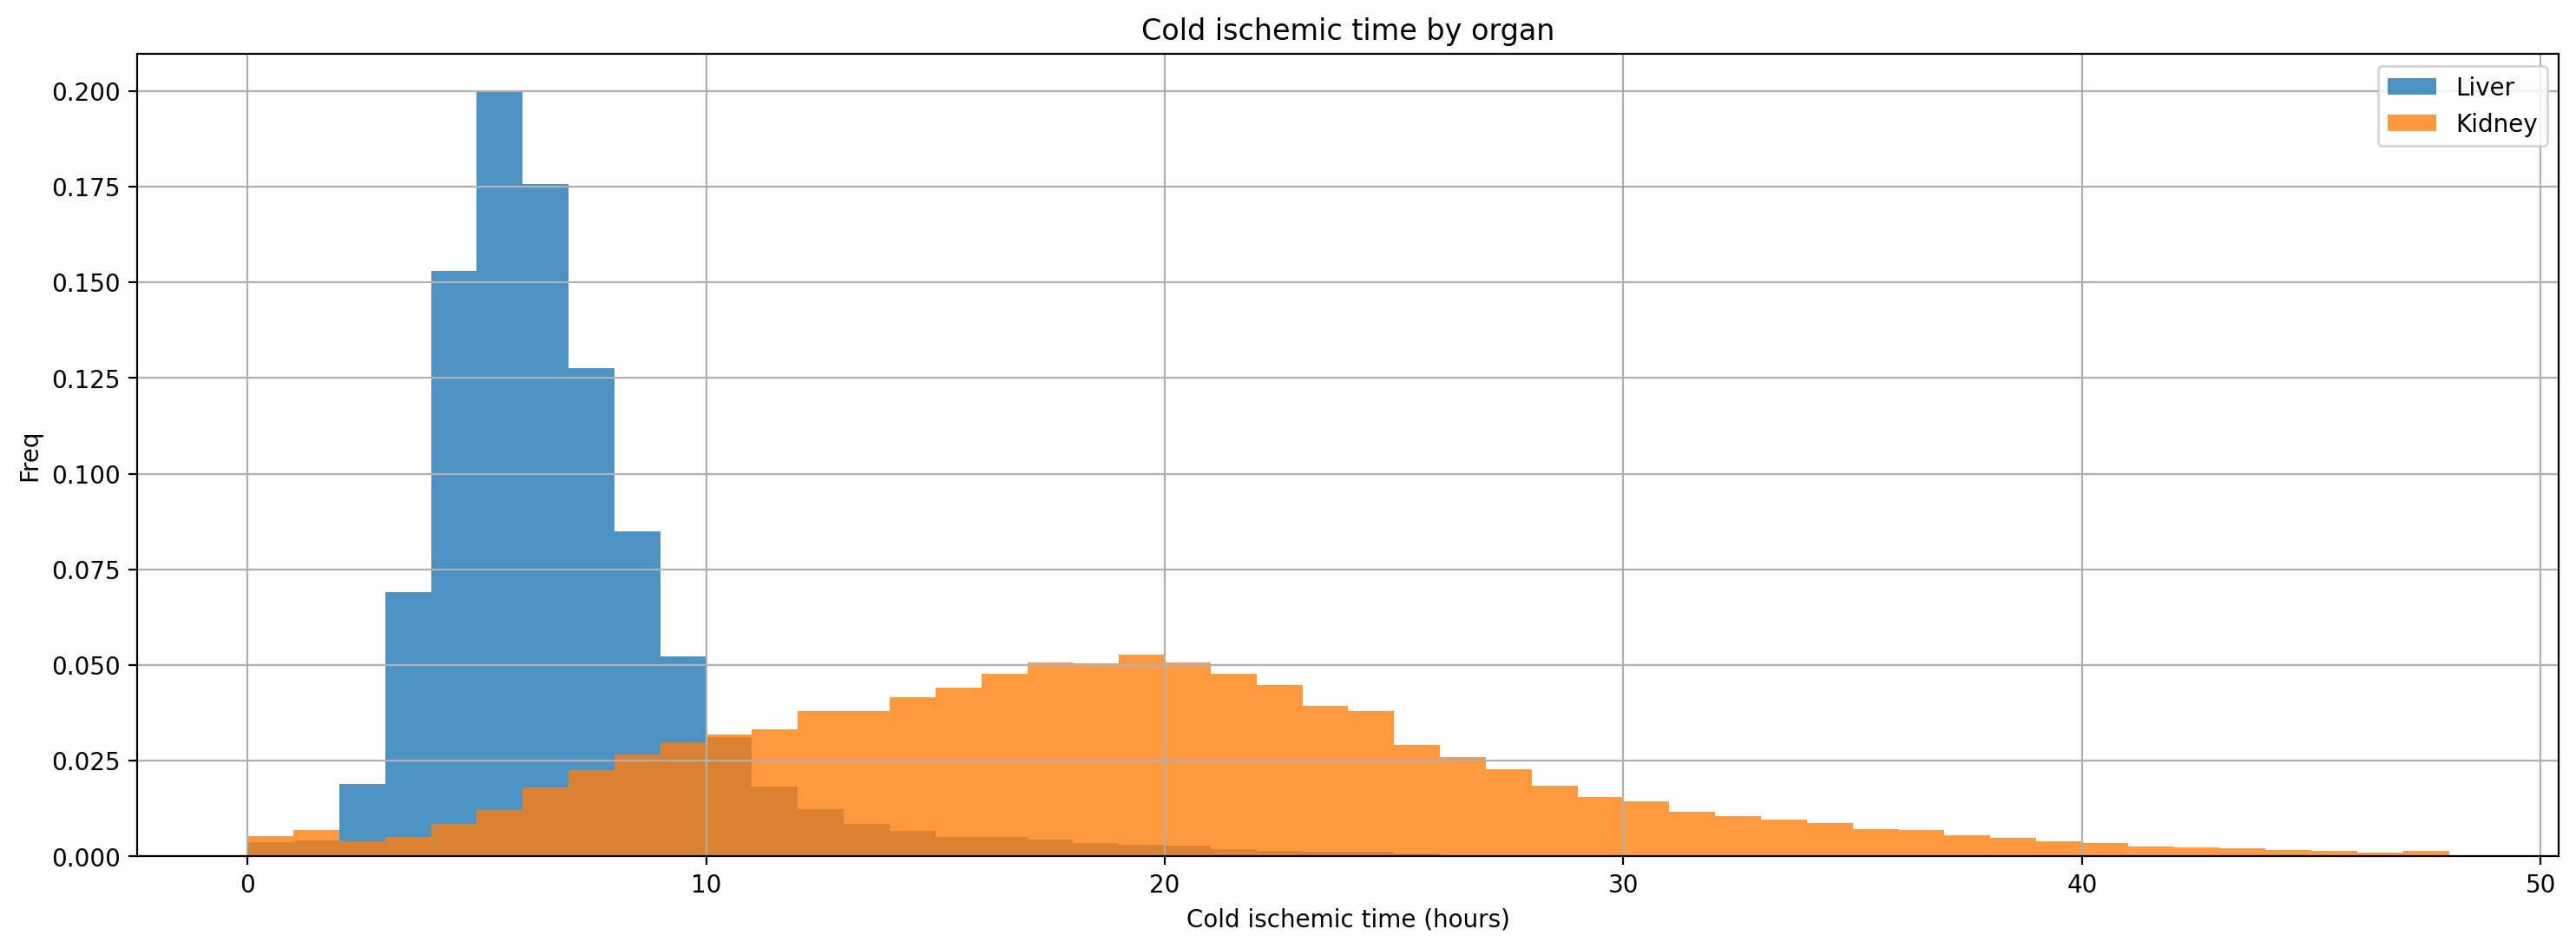

In [12]:
fig, ax = plt.subplots(figsize=(18, 6))
for organ in organs:
    organ_with_positive_travel_distance_mask = ((optn_df["organ"] == organ.lower()) & (optn_df["distance_miles"] > 0))
    optn_df[organ_with_positive_travel_distance_mask].hist(
        "preservation_hours",
        ax=ax,
        alpha=0.8,
        bins=range(0, 49),
        density=True,
        label=organ,
    )

ax.set_title("Cold ischemic time by organ")
ax.set_xlabel("Cold ischemic time (hours)")
ax.set_ylabel("Freq")
plt.legend()
plt.show()

So it looks like kidneys are on ice longer.  Does that mean they travel farther?

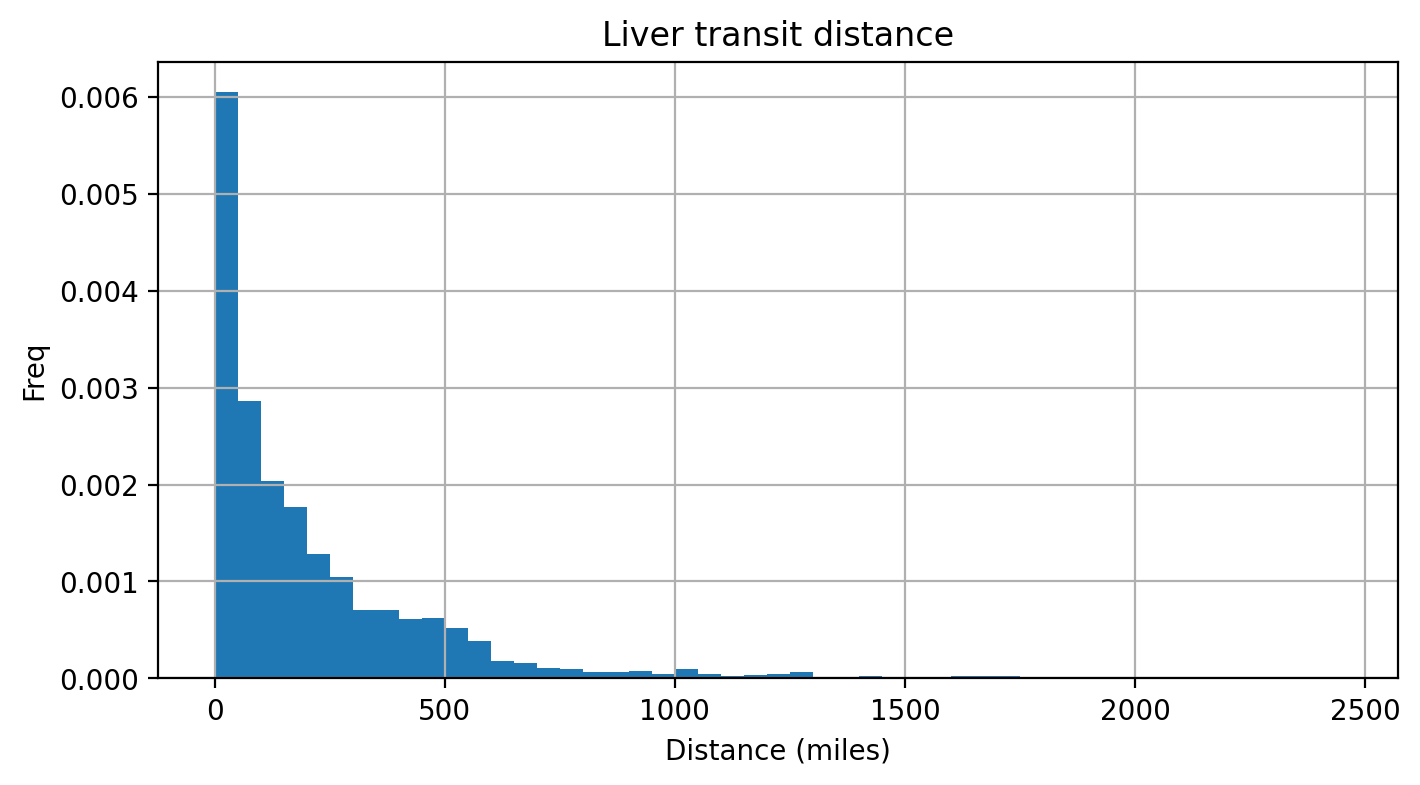

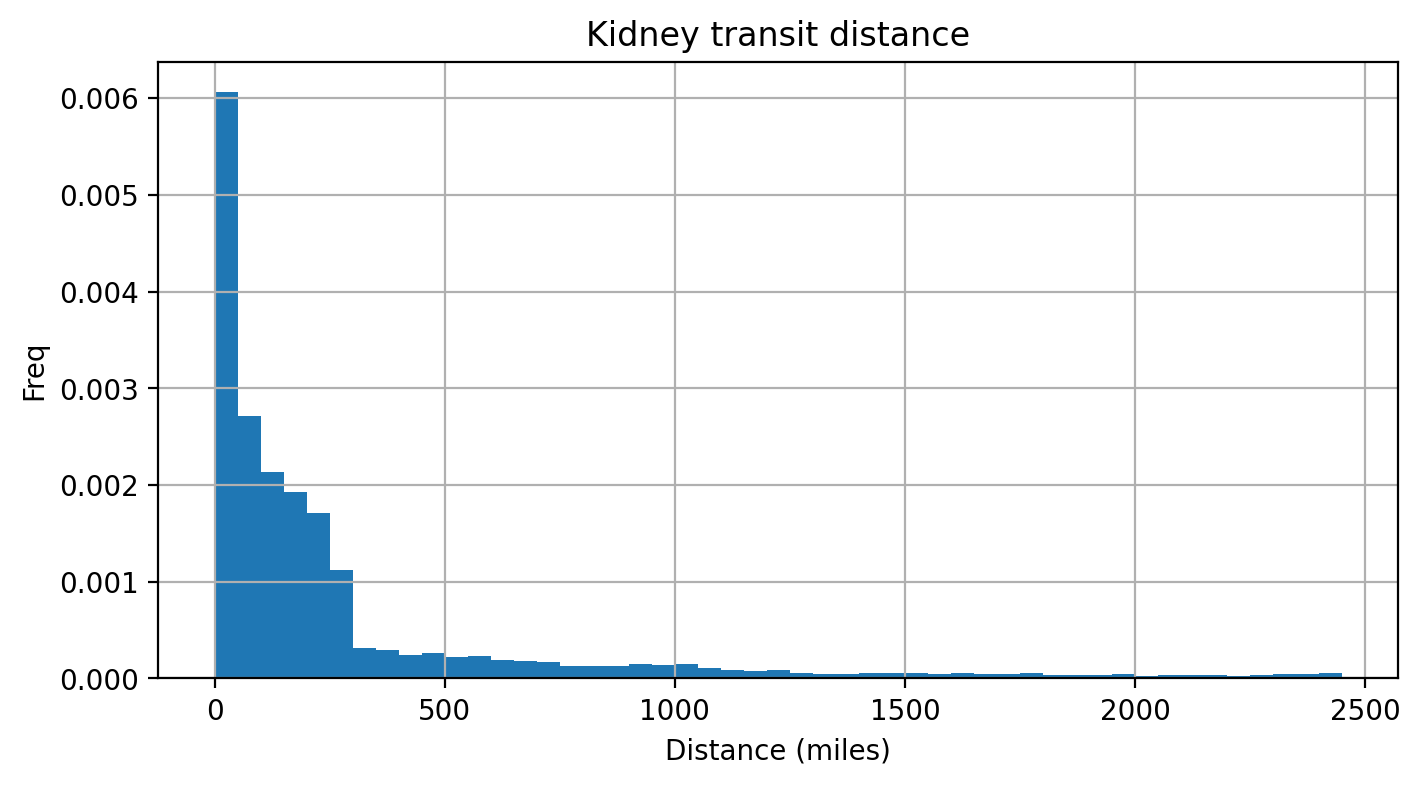

In [13]:
for organ in organs:
    fig, ax = plt.subplots(figsize=(8, 4))
    optn_df[(optn_df["organ"] == organ.lower()) & (optn_df["distance_miles"] > 0)].hist(
        "distance_miles", ax=ax, bins=range(0, 2500, 50),density=True, label=organ,
    )

    ax.set_title(f"{organ} transit distance")
    ax.set_xlabel("Distance (miles)")
    ax.set_ylabel("Freq")
    plt.show()

Maybe not.  There is a more complicated relationship between cold time and transit distance.

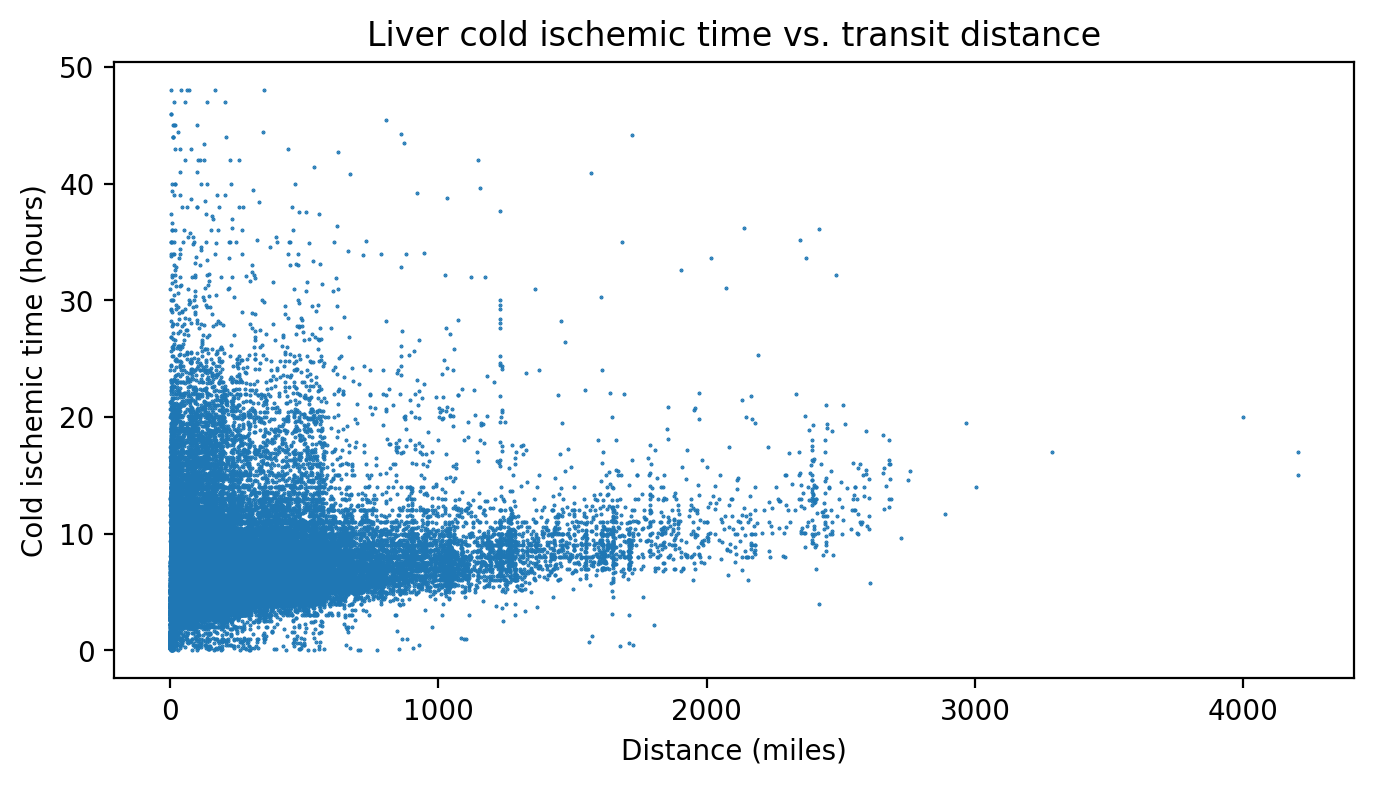

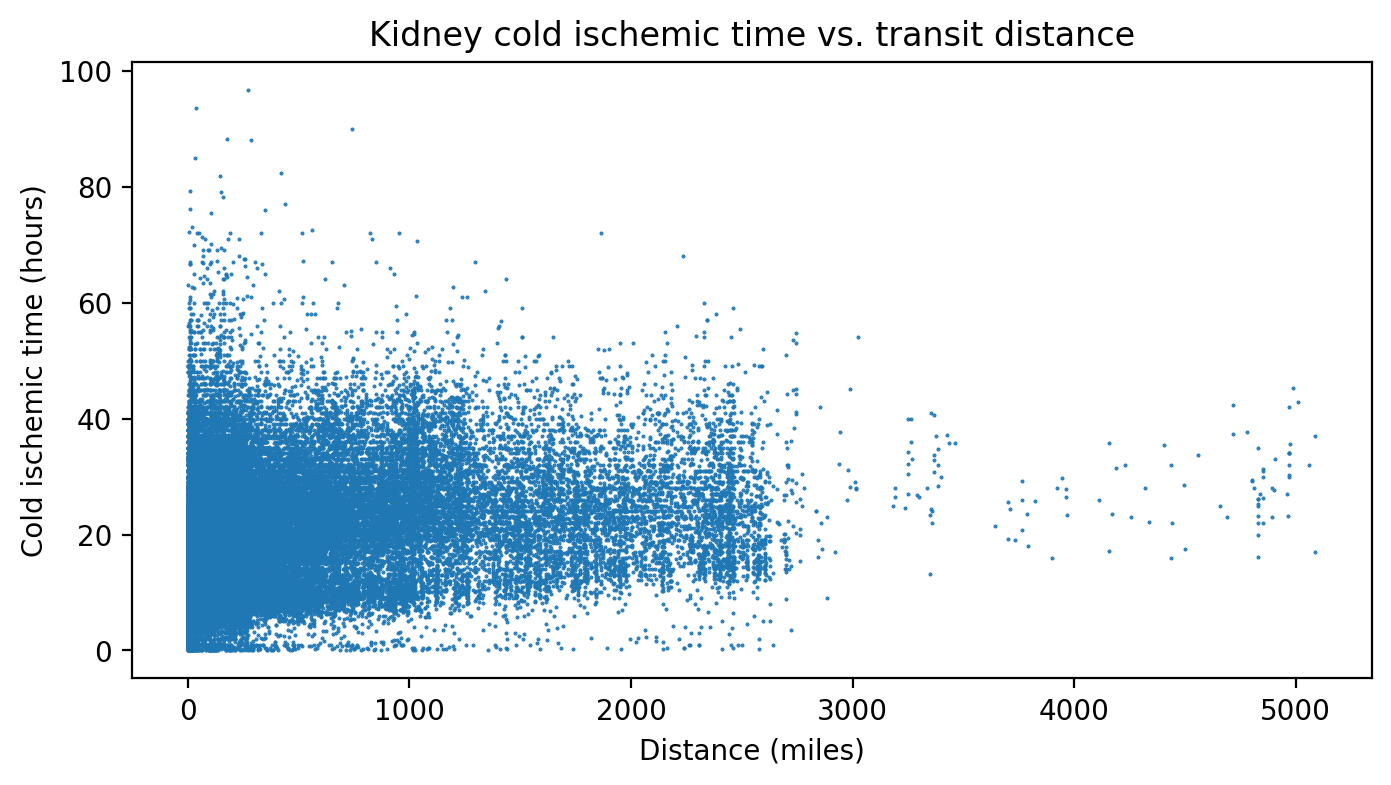

In [14]:
for organ in organs:
    fig, ax = plt.subplots(figsize=(8, 4))
    optn_df[(optn_df["distance_miles"] > 0) & (optn_df["organ"] == organ.lower())].plot.scatter(
        y="preservation_hours", x="distance_miles", ax=ax, s=0.2,
    )
    ax.set_title(f"{organ} cold ischemic time vs. transit distance")
    ax.set_xlabel("Distance (miles)")
    ax.set_ylabel("Cold ischemic time (hours)")
    plt.show()

#### DISCUSS - Analyze scatterplots

What do you see in the scatterplots? What is hidden in this way of plotting?  What might you test, or what other plots could you make, if you were trying to unpack this information further?



#### TASK 1 - build on scatterplots

There are many ways to build on the scatterplot.  You can try a histogram instead; you can color the points by some other variable in the dataframe to look for patterns.  You can also compare these to the pancreas data.  Make at least one new data visualization that probes the relationship between transit distance and time on ice.

One limitation of a scatterplot like the above is that it's hard to tell just how many points are in the dense areas. We can introduce a new plotting package called `seaborn` to visualize the same data with a KDE (kernel density estimate) plot.  This just takes the point data and smooths it out; color gradient also shows density.

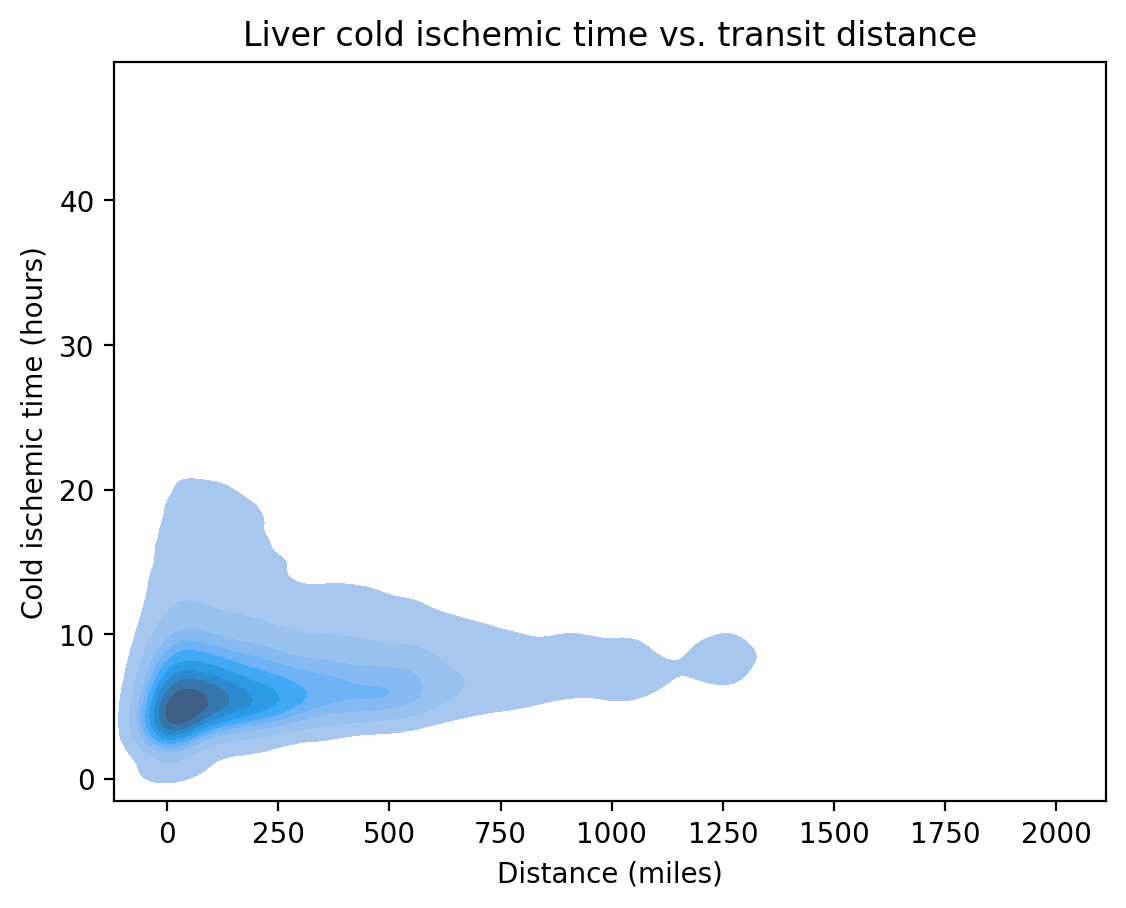

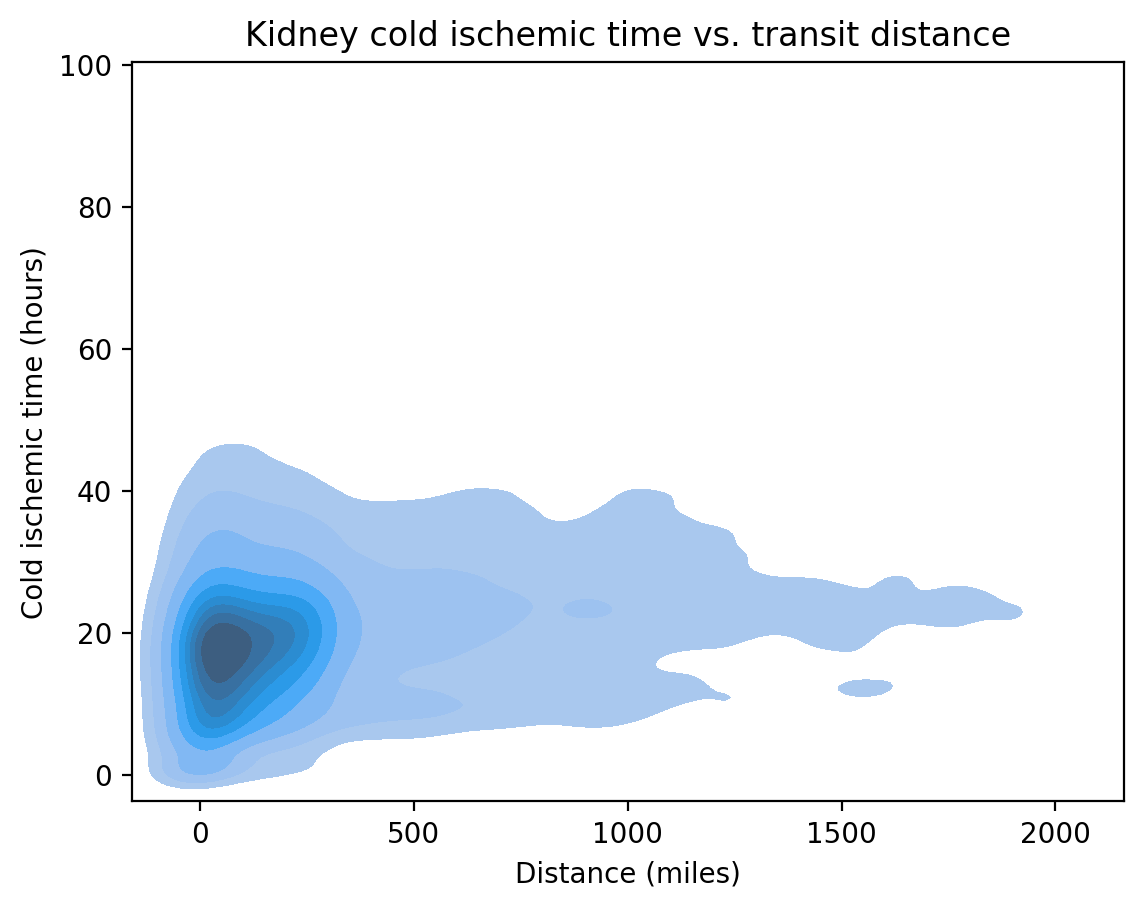

In [15]:
for organ in organs:
    joint_df = optn_df[
        (optn_df["distance_miles"] > 0) &
        (optn_df["organ"] == organ.lower()) &
        (optn_df["distance_miles"] <= 2000)
    ]
    ax = sns.kdeplot(
        data=joint_df,
        x="distance_miles",
        y="preservation_hours",
        fill=True,
    )
    ax.set_title(f"{organ} cold ischemic time vs. transit distance")
    ax.set_xlabel("Distance (miles)")
    ax.set_ylabel("Cold ischemic time (hours)")
    plt.show()

## Predicting 1-year success

Next, we'll introduce a basic technique called **logistic regression**.  
Just as linear regression produces a best-fit line, this
statistical technique uses binary data of success and failure and fits an S-shaped curve to the data, smoothly interpolating from 1 to 0.  The interpretation is that this is telling you an inferred PROBABILITY, learned from the data points.

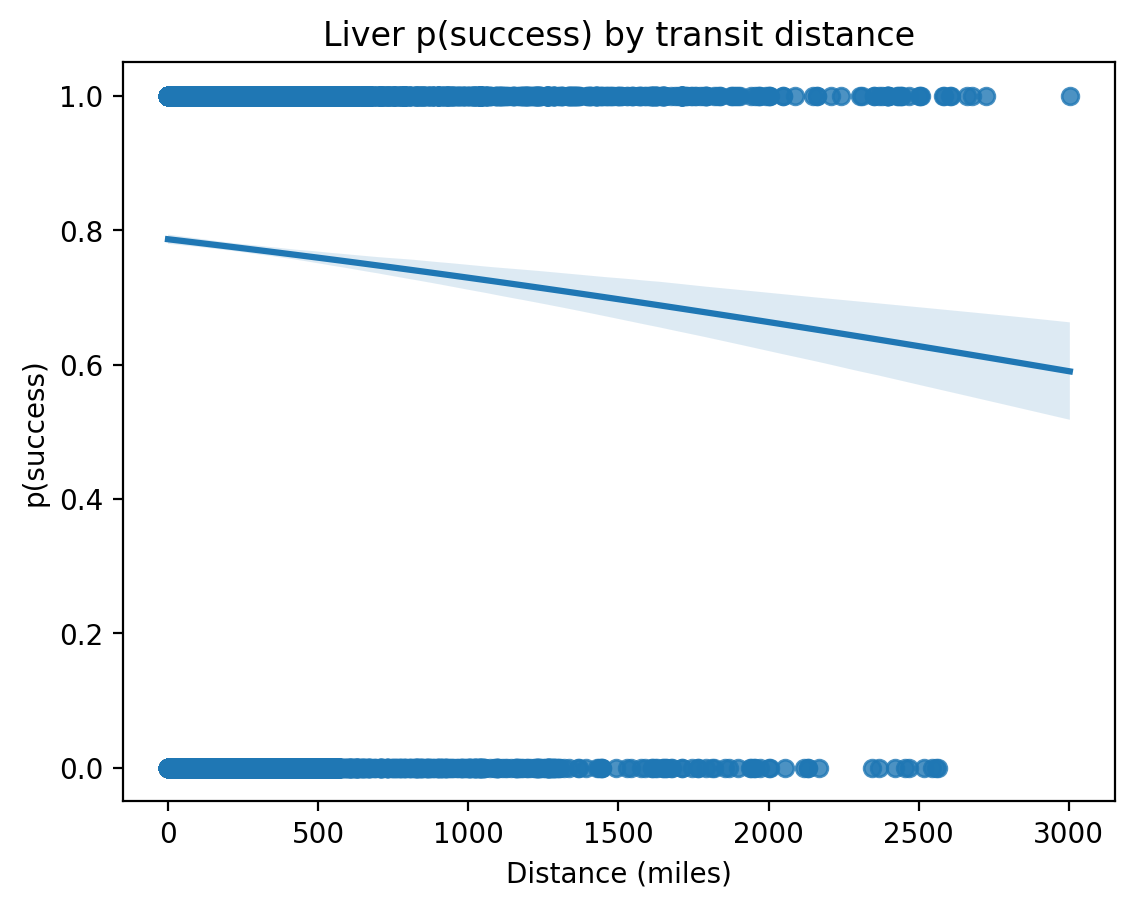

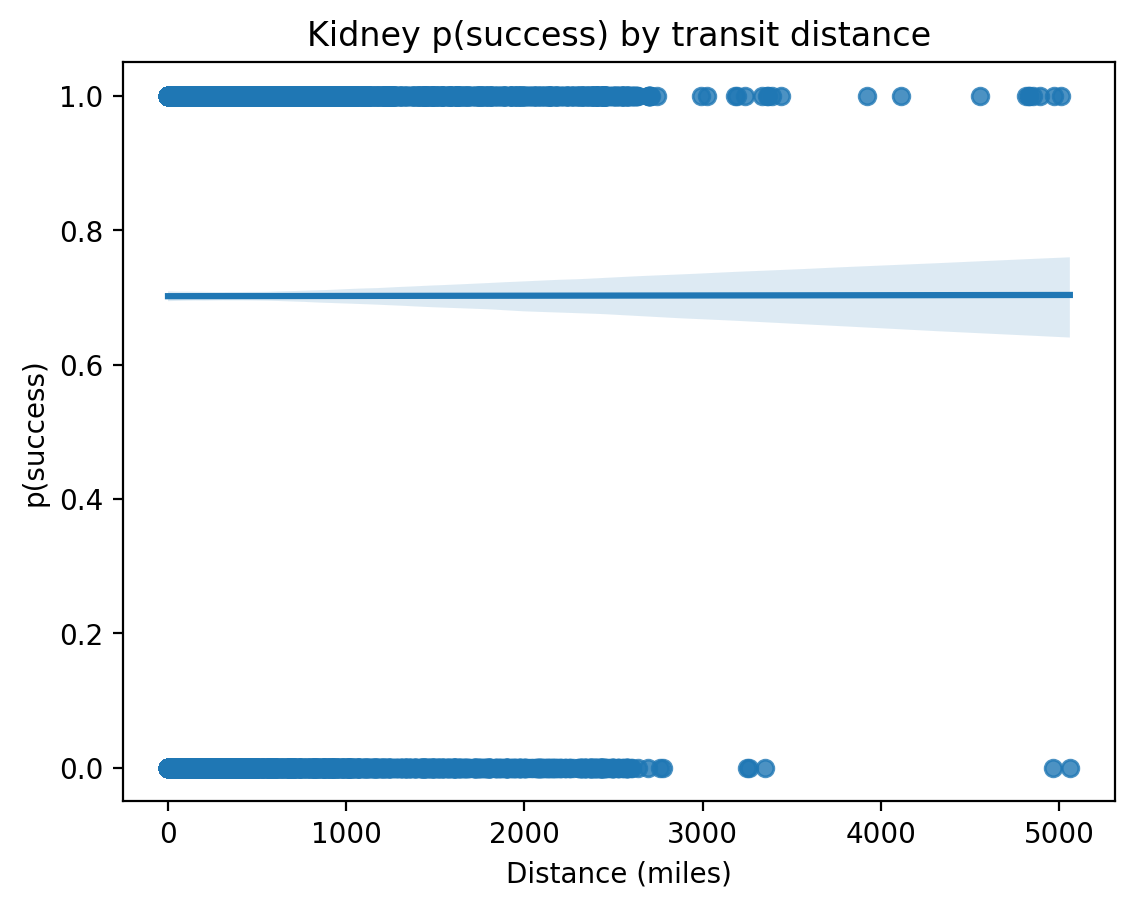

In [16]:
for organ in organs:
    success_df = optn_df[
        (optn_df["distance_miles"] > 0) &
        (optn_df["organ"] == organ.lower())
    ].sample(frac=0.2)  # `sample(frac=0.2)` randomly samples 20% of the data to speed up plotting
    ax = sns.regplot(
        data=success_df,
        x=success_df["distance_miles"],
        y=success_df["succeeded_1_year"],
        logistic=True,
    )
    ax.set_title(f"{organ} p(success) by transit distance")
    ax.set_xlabel("Distance (miles)")
    ax.set_ylabel("p(success)")
    plt.show()

#### DISCUSS - Interpret logistic regression

What are these saying?  Where's the S shape?

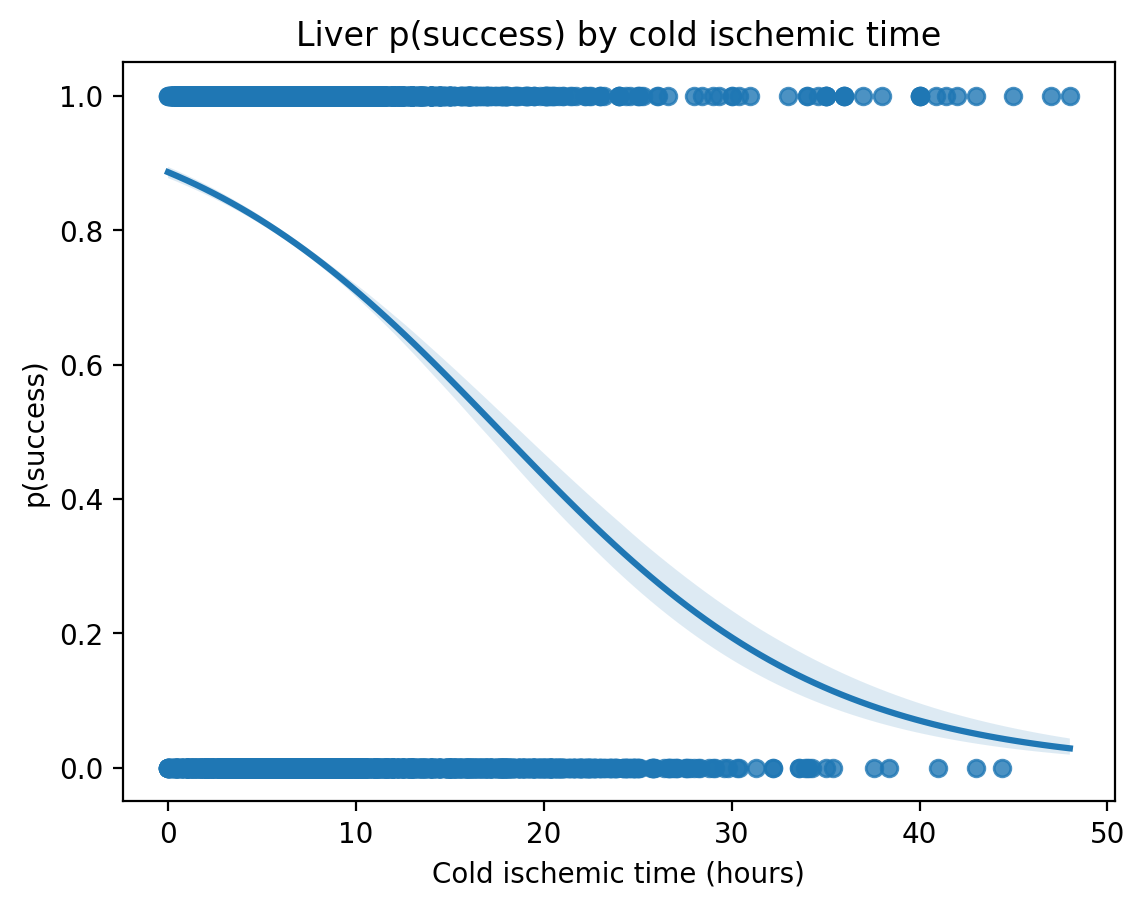

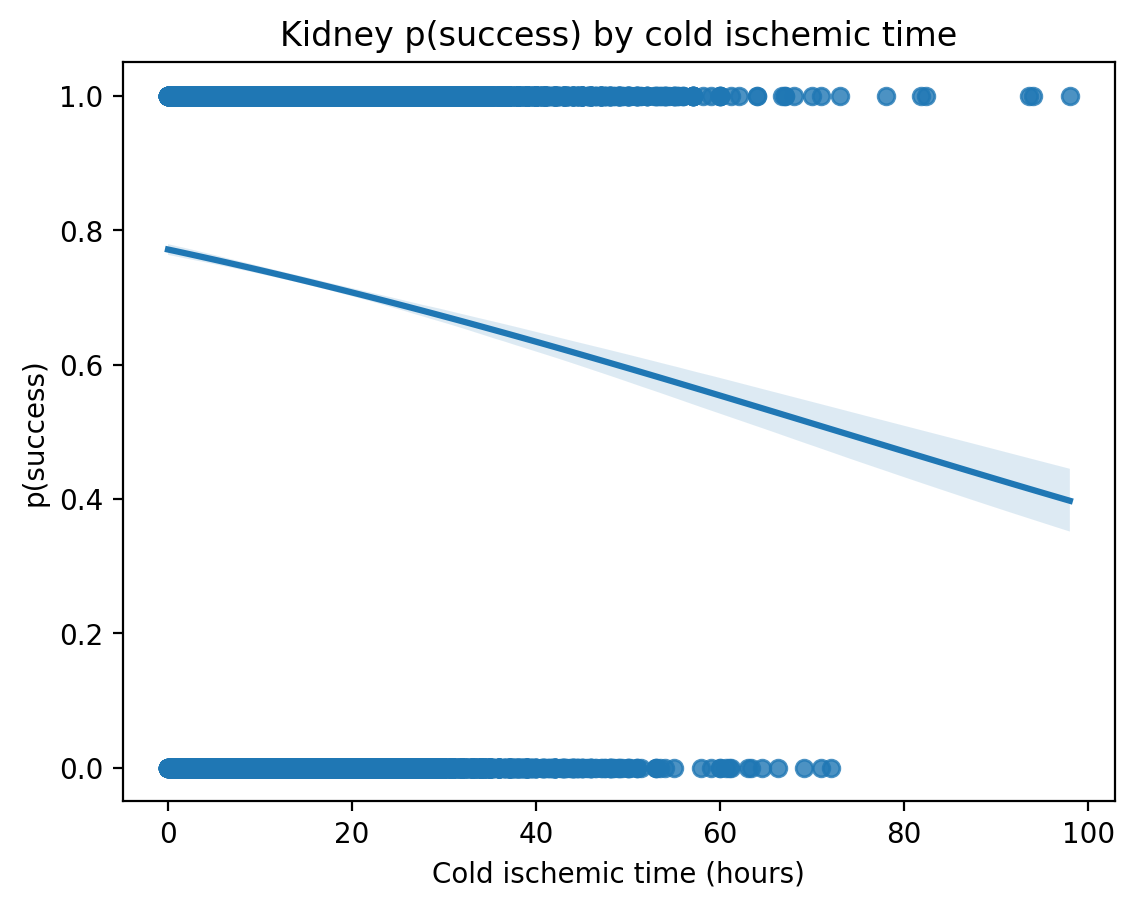

In [17]:
for organ in organs:
    success_df = optn_df[(optn_df["organ"] == organ.lower())].sample(frac=0.2)
    ax = sns.regplot(
        data=success_df,
        x=success_df["preservation_hours"],
        y=success_df["succeeded_1_year"],
        logistic=True,
    )
    ax.set_title(f"{organ} p(success) by cold ischemic time")
    ax.set_xlabel("Cold ischemic time (hours)")
    ax.set_ylabel("p(success)")
    plt.show()

#### DISCUSS - Confidence

The lighter-shaded blue area is a *confidence band*, like a confidence interval for this inference process. Why does the width of the band increase as cold ischemic time rises?  

#### TASK 2 - Counts

Use dataframe operations to provide the count of liver transplants (and separately kidney transplants) recorded in the data per cold ischemic time.

Hint: create new filtered dataframe and try the `value_counts()` method.


## Transplant volume by Census region/division

Everything we did above was using geospatial data basically just to see how far organs are shipped.  In this section we'll pay attention to where they are sent FROM and TO.

We'll use 4 census regions (Northeast, Midwest, South, and West) and we'll also subdivide those a little more finely into nine "[divisions](https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf)," to get a feel for how organs move around the country.

In [18]:
try:
    region_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_region_500k.zip")
except Exception:
    region_gdf = read_parquet_from_github("https://github.com/ds-20195/notebooks/raw/refs/heads/main/backup_data/Notebook5_region_gdf.parquet")

try:
    division_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_division_500k.zip")
except Exception:
    division_gdf = read_parquet_from_github("https://github.com/ds-20195/notebooks/raw/refs/heads/main/backup_data/Notebook5_division_gdf.parquet")

## Spatial Indexing in GeoDataFrames

In addition to the standard index, GeoDataFrames come equipped with and spatial index which allows
us to query (filter) the dataframe using geometries. This is how we **identify** what geographic unit a point belongs to.

In [19]:
division_gdf

,DIVISIONCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,1,0300000US1,1,New England,69,162376417481,24072855206,"MULTIPOLYGON (((-67.32259 44.6116, -67.32174 4..."
1,2,0300000US2,2,Middle Atlantic,69,256981418064,26186444931,"MULTIPOLYGON (((-72.03683 41.24984, -72.03496 ..."
2,3,0300000US3,3,East North Central,69,629289745590,151252485939,"MULTIPOLYGON (((-82.73571 41.60336, -82.73392 ..."
3,4,0300000US4,4,West North Central,69,1314707528663,33020781573,"MULTIPOLYGON (((-89.59206 47.96668, -89.59147 ..."
4,5,0300000US5,5,South Atlantic,69,687099317084,71741527671,"MULTIPOLYGON (((-75.56555 39.51485, -75.56174 ..."
5,8,0300000US8,8,Mountain,69,2216504548727,20112368319,"POLYGON ((-120.00574 39.22866, -120.00559 39.2..."
6,9,0300000US9,9,Pacific,69,2319697198955,296474924140,"MULTIPOLYGON (((-147.17351 60.91154, -147.1700..."
7,6,0300000US6,6,East South Central,69,461789786924,13245708132,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
8,7,0300000US7,7,West South Central,69,1100982564361,49097374744,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."


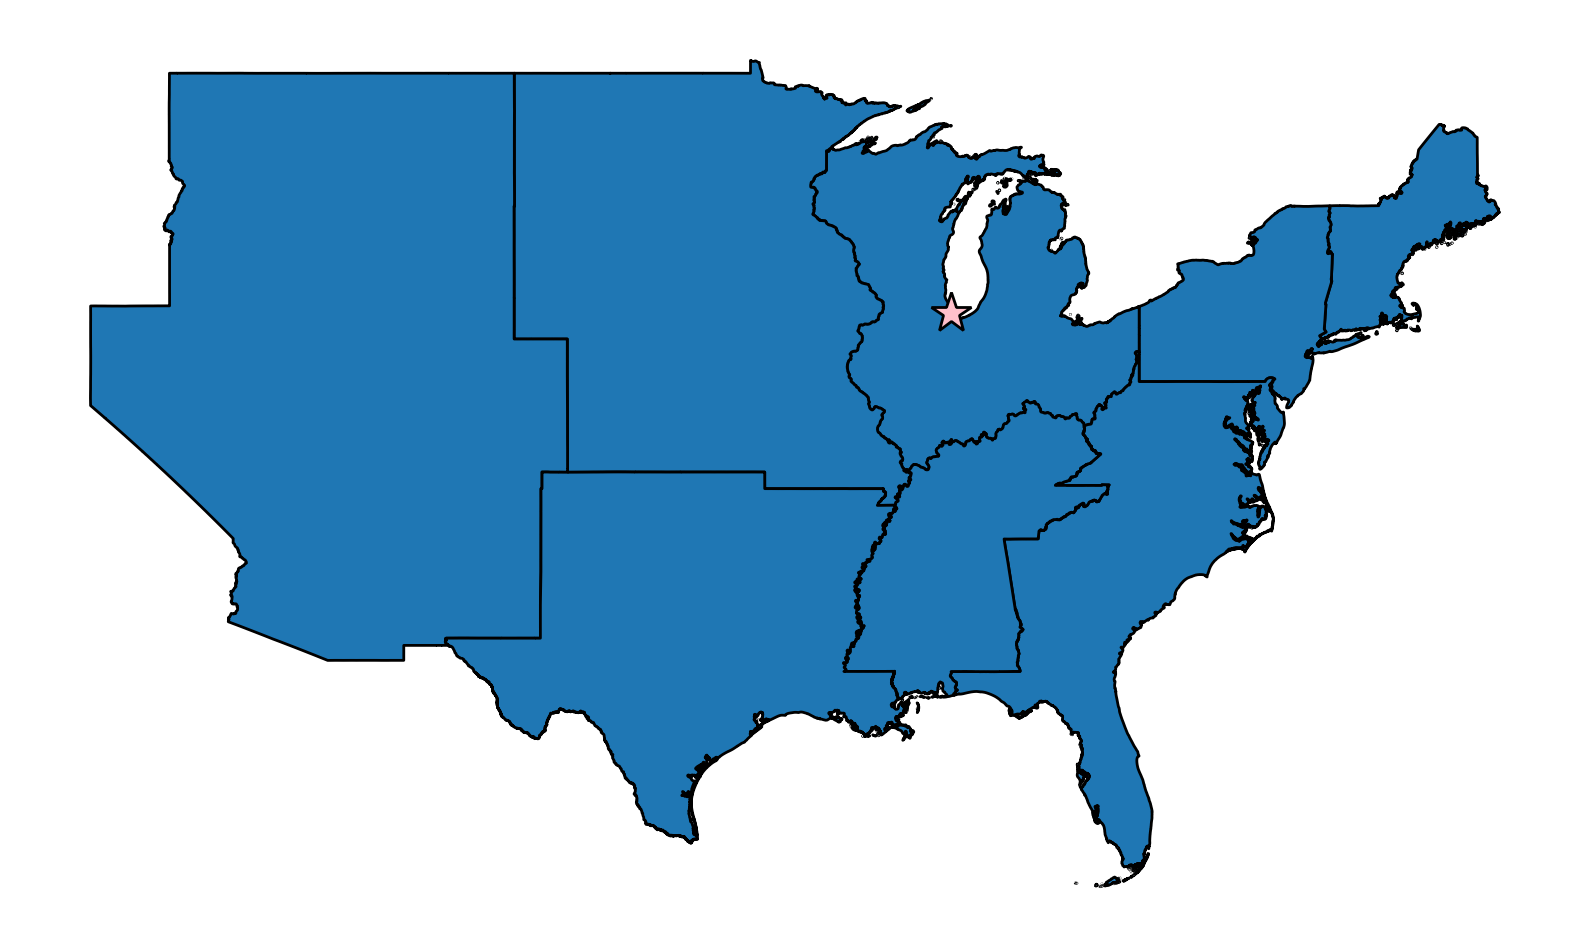

In [29]:
 ryerson_pt = Point(-87.5992125601424, 41.790627892683034) # Note: Point takes (lon, lat) order

fig, ax = plt.subplots(figsize=(10,10))

# We exclude the Pacific division because Alaska and Hawaii are a little harder to handle.
division_gdf.loc[division_gdf["NAME"] != "Pacific"].plot(ax=ax, edgecolor="black")
ax.plot(ryerson_pt.x, ryerson_pt.y, marker="*", color="pink", markersize=15, markeredgecolor="black")
ax.set_axis_off()
plt.show()

Now we query the spatial index to find the geographical division containing UChicago. Note that `sindex.query` returns a list of row numbers (which may not be the same as the dataframe index), so we use `iloc` to isolate the correct dataframe view.

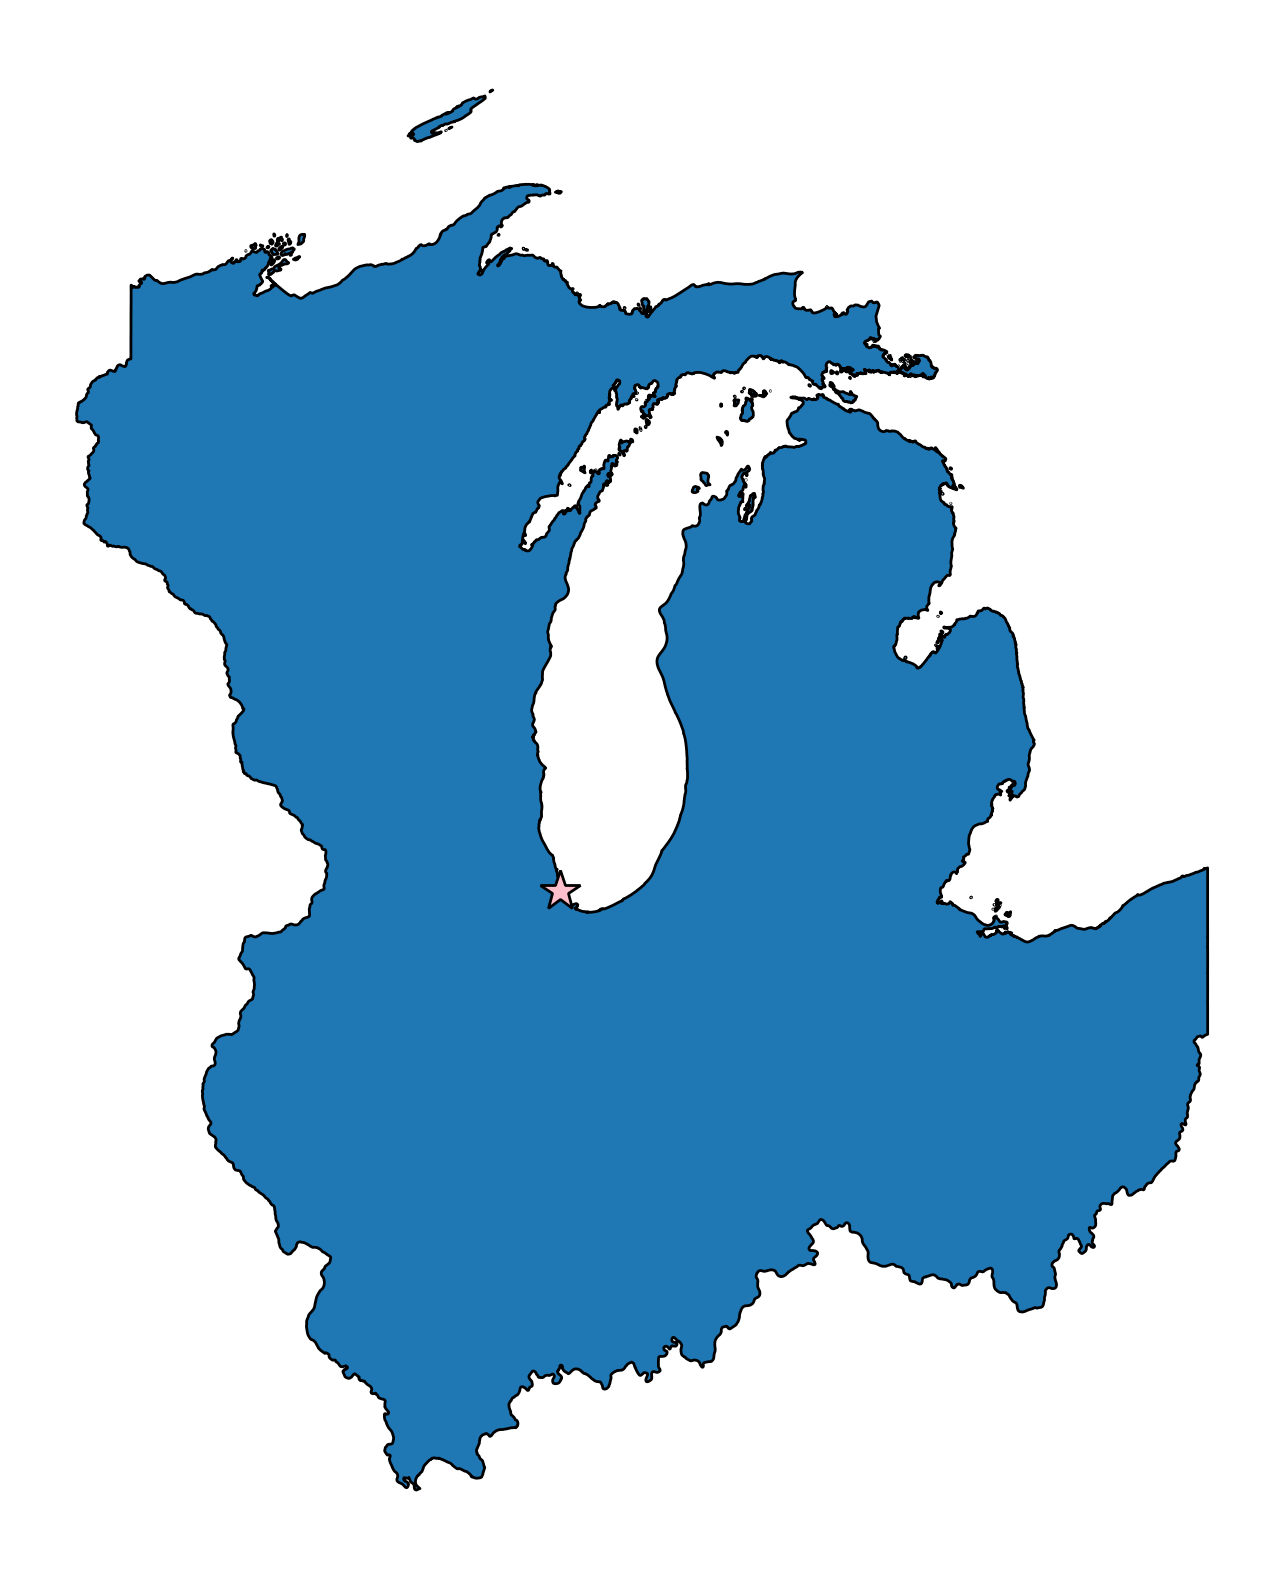

In [30]:
ryerson_division_row_integer_index = division_gdf.sindex.query(ryerson_pt, predicate="intersects")
ryerson_division_gdf = division_gdf.iloc[ryerson_division_row_integer_index]

fig, ax = plt.subplots(figsize=(10,10))

ryerson_division_gdf.plot(ax=ax, edgecolor="black")
ax.plot(ryerson_pt.x, ryerson_pt.y, marker="*", color="pink", markersize=15, markeredgecolor="black")
ax.set_axis_off()
plt.show()

####TASK 3 - find a point

Choose your home address (if in the continental US), or another location (Disneyland, Wall Drug, the White House, you name it!).  Plot it with a different marker and identify its region.

We can now use spatial indexing to construct a function that identifies regions for the donor and recipient hospitals.

In [22]:
def loc_to_label(row, label_gdf, prefix, previously_seen_loc_dict=None):
    coords = (row[f"{prefix}_lon"], row[f"{prefix}_lat"])
    if previously_seen_loc_dict is None:
       previously_seen_loc_dict = {}

    if coords in previously_seen_loc_dict:
        return previously_seen_loc_dict[coords]

    p = Point(coords[0], coords[1])
    row_index_containing_point = label_gdf.sindex.query(p, predicate="intersects")
    matches = label_gdf.iloc[row_index_containing_point]
    if not len(matches):
        return "N/A"

    assert len(matches) == 1
    previously_seen_loc_dict[coords] = matches.iloc[0]["NAME"]
    return matches.iloc[0]["NAME"]

We wish to apply this function to each row in `optn_df` using `optn_df.apply`, but funcions passed to `apply` can only accept a single parameter -- the row of the dataframe. So we build a function constructor that partially fills in the parameters of `loc_to_label` ahead of time.

In [23]:
def build_loc_labeler_function(label_gdf, prefix, previously_seen_loc_dict=None):

    # We will return this function, which now only accepts a row of the dataframe.
    # That the passed values of `label_gdf`, `prefix`, and `previously_seen_loc_dict` are
    # "baked into" the returned function, so we don't have to pass them in every time.
    def inner_loc_to_label_function(row):
        return loc_to_label(row, label_gdf, prefix, previously_seen_loc_dict)

    return inner_loc_to_label_function

In [24]:
previously_seen_region_dict = {}

transplant_region_labeler_function = build_loc_labeler_function(
    label_gdf=region_gdf,
    prefix="transplant",
    previously_seen_loc_dict=previously_seen_region_dict
)
optn_df["transplant_census_region"] = optn_df.apply(
    transplant_region_labeler_function,
    axis=1,
)

donor_region_labeler_function = build_loc_labeler_function(
    label_gdf=region_gdf,
    prefix="donor",
    previously_seen_loc_dict=previously_seen_region_dict
)
optn_df["donor_census_region"] = optn_df.apply(
    donor_region_labeler_function,
    axis=1,
)

In [25]:
previously_seen_division_dict = {}

transplant_division_labeler_function = build_loc_labeler_function(
    label_gdf=division_gdf,
    prefix="transplant",
    previously_seen_loc_dict=previously_seen_division_dict
)
optn_df["transplant_census_division"] = optn_df.apply(
    transplant_division_labeler_function,
    axis=1,
)

donor_division_labeler_function = build_loc_labeler_function(
    label_gdf=division_gdf,
    prefix="donor",
    previously_seen_loc_dict=previously_seen_division_dict
)
optn_df["donor_census_division"] = optn_df.apply(
    donor_division_labeler_function,
    axis=1,
)

Now we've packed this information into our dataframe.  We've got columns for how long the organ was preserved, for the donor and recipient age (chunked as 0-29, 30-59, or 60+ years old) and we'll show whether the graft was marked successful after one year.

(Later, if you request more of the data in the sqlite file, you'll see columns for success to 6 months, 2 years, etc.)

In [26]:
optn_df

,preservation_hours,recipient_age,donor_age,organ,deceased_donor,succeeded_1_year,donor_lat,donor_lon,transplant_lat,transplant_lon,transplant_year,distance_miles,transplant_census_region,donor_census_region,transplant_census_division,donor_census_division
0,6.1,30-59,60-99,liver,True,True,43.15,-75.18,42.27,-71.76,2017-2024,184.370227,Northeast,Northeast,New England,Middle Atlantic
1,5.0,60-99,0-29,liver,True,True,41.25,-75.88,39.96,-75.20,2007-2016,95.925424,Northeast,Northeast,Middle Atlantic,Middle Atlantic
2,5.7,30-59,30-59,liver,True,False,38.03,-84.51,35.13,-90.00,2017-2024,364.858865,South,South,East South Central,East South Central
3,7.5,30-59,60-99,liver,True,True,37.66,-121.02,37.76,-122.46,2007-2016,79.198770,West,West,Pacific,Pacific
4,5.3,30-59,0-29,liver,True,False,39.70,-104.84,40.66,-111.89,2017-2024,378.821725,West,West,Mountain,Mountain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252054,9.4,30-59,30-59,pancreas,True,True,39.68,-105.16,32.24,-110.94,2017-2024,606.372260,West,West,Mountain,Mountain
252055,0.2,30-59,0-29,pancreas,True,True,40.65,-73.93,40.79,-73.94,2017-2024,9.674583,Northeast,Northeast,Middle Atlantic,Middle Atlantic
252056,15.5,30-59,30-59,pancreas,True,True,39.32,-81.51,40.00,-83.02,2007-2016,93.186212,Midwest,South,East North Central,South Atlantic
252057,10.5,30-59,0-29,pancreas,True,False,33.51,-86.80,38.92,-77.09,2017-2024,657.765094,South,South,South Atlantic,East South Central


In [27]:
pd.crosstab(optn_df["transplant_census_region"], optn_df["donor_census_region"])

donor_census_region,Midwest,N/A,Northeast,South,West
transplant_census_region,,,,,
Midwest,54830,21,1355,5090,1642
Northeast,1987,115,33342,5545,835
South,4447,1060,4655,87426,1950
West,1651,9,588,1822,43689


In [28]:
pd.crosstab(optn_df["transplant_census_division"], optn_df["donor_census_division"])

donor_census_division,East North Central,East South Central,Middle Atlantic,Mountain,N/A,New England,Pacific,South Atlantic,West North Central,West South Central
transplant_census_division,,,,,,,,,,
East North Central,34975,1667,884,325,19,157,405,1493,1815,502
East South Central,869,10659,113,102,101,33,118,2241,495,566
Middle Atlantic,1307,491,25135,319,100,1570,430,3984,484,495
Mountain,184,87,150,11454,3,49,1213,209,756,391
New England,132,98,1085,44,15,5552,42,390,64,87
Pacific,434,176,286,4690,6,103,26332,536,277,423
South Atlantic,1682,3715,3773,495,860,467,638,41920,564,1520
West North Central,2098,394,233,645,2,81,267,487,15942,547
West South Central,330,1015,214,311,99,55,286,1311,507,24479


# Homework 5

**Warmup question**: choose one census division from the table above, and choose one hospital in that division.  Figure out what city that hospital is in (reverse geocoding!).  You can do this in Google Maps, for example.  For that hospital, how many liver transplants did it receive in this whole dataset?  Explain how you figured it out.

**Data product**: Formulate a question and make a data product that addresses it.  Briefly explain how you made it.

**Reading question**: This week's reading is by Kieran Healy on the sociology of organ donation.  He spends a good deal of space in the chapter discussing the ways that organ donation falls into a public policy gray area---is it best handled as a *gift* or by a *market*?  Pick out one quote from the chapter that relates to this tension between virtue and incentives.  Then give another example, not already covered in the chapter or the class discussion, of a policy question that falls in a gray area between gifts and markets.  Be creative!